|                |   |
:----------------|---|
| **Nombre**     | Valeria Guzmán Galván  |
| **Fecha**      | 04/05/2026  |
| **Expediente** | 756902  |

# T09 - Resampling

Completa los ejercicios (5.4) conceptuales y prácticos del capítulo “Resampling” (5) del libro ISLP.

## 5.4 Ejercicios Conceptuales

### **1. Usando propiedades básicas de la varianza, así como cálculo de una variable, deriva la ecuación (5.6). En otras palabras, demuestra que el valor de α dado por (5.6) minimiza: Var(αX + (1 − α)Y ).**

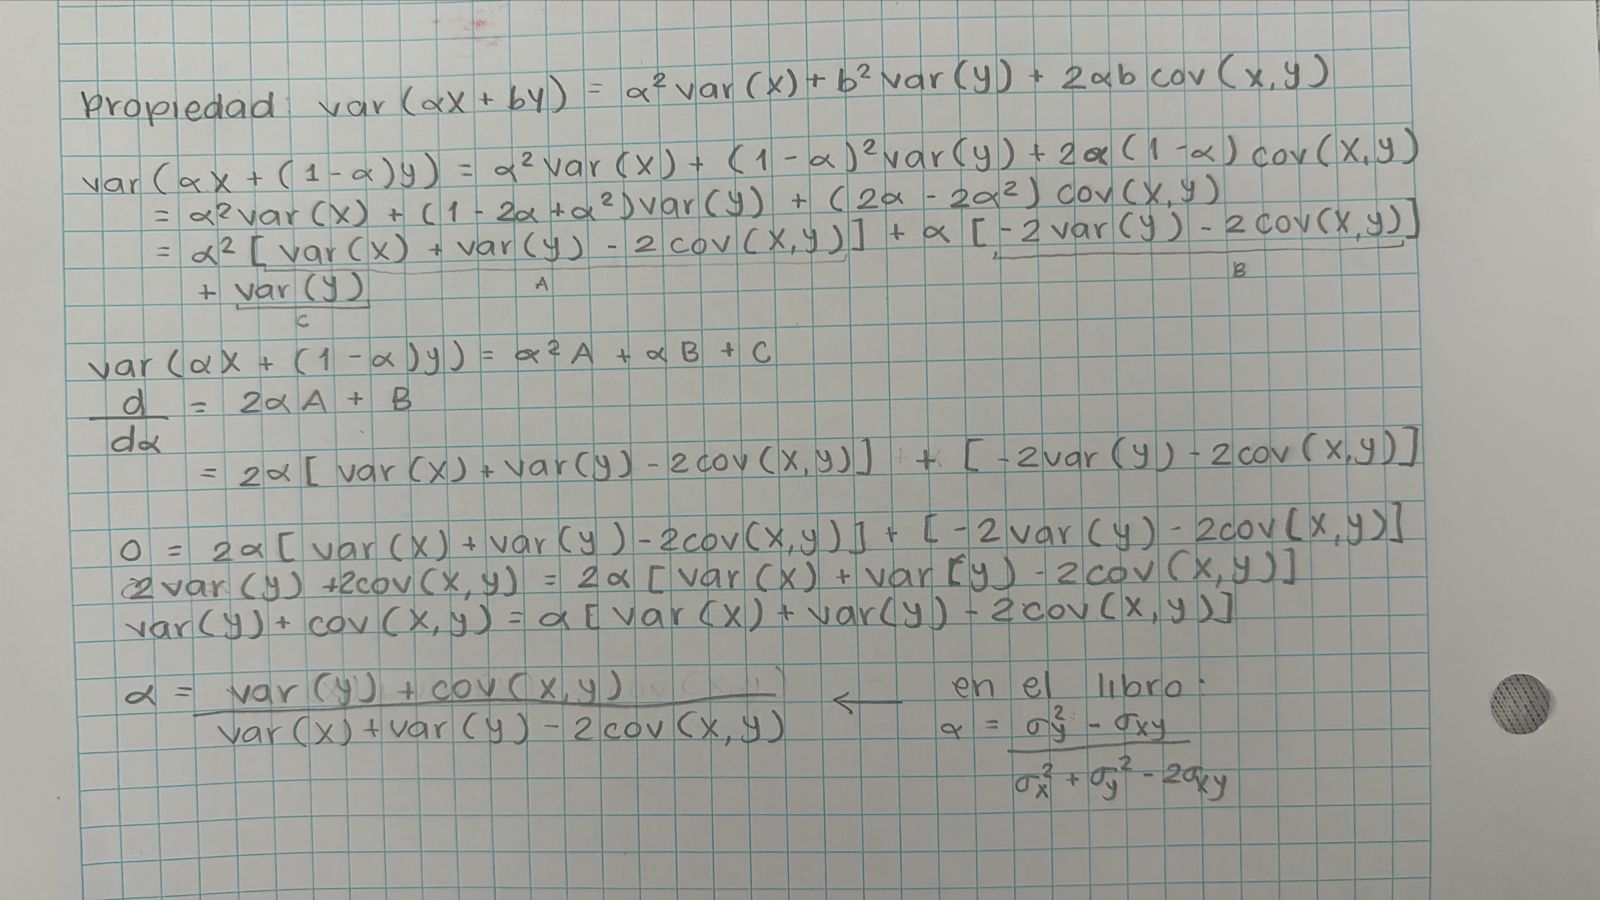

### **2. Ahora derivaremos la probabilidad de que una observación dada forme parte de una muestra bootstrap. Suponga que obtenemos una muestra bootstrap a partir de un conjunto de n observaciones.**

**a) ¿Cuál es la probabilidad de que la primera observación bootstrap no sea la observación número j del conjunto original? Justifique su respuesta.**

En el muestreo bootstrap, cada observación se selecciona de manera aleatoria y con reemplazo de un conjunto de n observaciones, por lo que todas tienen la misma probabilidad de ser elegidas en cada extracción.

La probabilidad de que la primera observación bootstrap sea la observación j-ésima es de 1/n. Por lo tanto, la probabilidad de que no sea la observación j-ésima es 1 - 1/n

**b) ¿Cuál es la probabilidad de que la segunda observación bootstrap no sea la observación j-ésima del conjunto original?**

La probabilidad de que la segunda observación bootstrap no sea la observación j-ésima es de 1 - 1/n.

Esto se debe a que, al realizar el muestreo con reemplazo, cada selección es independiente y cada observación tiene probabilidad 1/n de ser elegida en cualquier extracción.

**c) Argumente que la probabilidad de que la observación j-ésima no esté en la muestra bootstrap es: (1 - 1/n)^n**

En cada una de las n extracciones la probabilidad de no seleccionar dicha observación es 1 - 1/n, y como las extracciones son independientes, se multiplican las probabilidades.

**d) Cuando n=5, ¿cuál es la probabilidad de que la observación j-ésima sí esté en la muestra bootstrap?**

Del inciso c) sabemos que la probabilidad de que no esté es de (1 - 1/n)^n. Por lo tanto la probabilidad de que sí esté es de 1 - (1 - 1/n)^n

Sustituyendo n = 5:

1 - (1 - 1/5)^5 = 0.6723

La probabilidad de que la observación j-ésima esté en la muestra bootstrap es de 0.6723

**e) Cuando n=100, ¿cuál es la probabilidad de que la observación j-ésima sí esté en la muestra bootstrap?**

Del inciso c) sabemos que la probabilidad de que no esté es de (1 - 1/n)^n. Por lo tanto la probabilidad de que sí esté es de 1 - (1 - 1/n)^n

Sustituyendo n = 100:

1 - (1 - 1/100)^100 = 0.634

La probabilidad de que la observación j-ésima esté en la muestra bootstrap es de 0.634

**e) Cuando n=10,000, ¿cuál es la probabilidad de que la observación j-ésima sí esté en la muestra bootstrap?**

Usamos:

1 - (1 - 1/n)^n

Cuando n es grande:

(1 - 1/n)^n = e^(-1)

P = 1 - e^(-1) = 1 - 0.367879 = 0.632121

La probabilidad de que la observación j-ésima esté en la muestra bootstrap es de 0.632121

**f) Crea una gráfica que muestre, para cada valor entero de n de 1 a 100,000, la probabilidad de que la observación j-ésima esté en la muestra bootstrap. Comenta qué observas.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

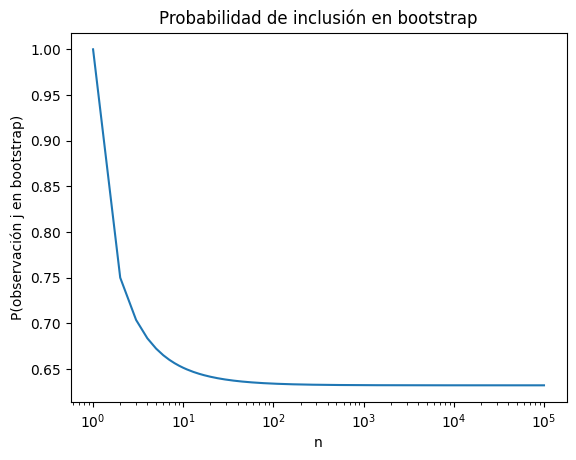

In [ ]:
n = np.arange(1, 100001)
p = 1 - (1 - 1/n)**n

plt.plot(n, p)
plt.xscale('log')
plt.xlabel("n")
plt.ylabel("P(observación j en bootstrap)")
plt.title("Probabilidad de inclusión en bootstrap")
plt.show()

La gráfica muestra que, conforme aumenta n, la probabilidad se acerca a un valor cercano a 0.632 y se mantiene estable

**h) Ahora investigaremos numéricamente la probabilidad de que una muestra bootstrap de tamaño n=100 contenga la observación j-ésima. En este caso j=4.**

**Primero creamos un array store que será llenado usando la función np.empty(). Luego, repetidamente creamos muestras bootstrap y cada vez registramos si la quinta observación está contenida en la muestra bootstrap.**

**Comente sobre los resultados obtenidos.**

In [ ]:
rng = np.random.default_rng(10)
store = np.empty(10000)
for i in range(10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0
np.mean(store)

np.float64(0.6362)

El resultado obtenido mediante simulación es aproximadamente 0.6362, el cual es muy cercano al valor teórico de 0.632.

Esto confirma que la probabilidad de que una observación esté incluida en una muestra bootstrap de tamaño 100 se aproxima a 63.2%, validando el resultado teórico.

### **3. K-fold Cross Validation**

**a) Explica cómo se implementa la validación cruzada de tipo k-fold**

Consiste en dividir el dataset en k grupos de tamaño similar.

En cada iteración, uno de los grupos se utiliza como conjunto de validación y los k-1 restantes como conjunto de entrenamiento. Este proceso se repite k veces, de modo que cada grupo se utiliza una vez como validación.

Finalmente, se calcula el promedio de los errores obtenidos en cada iteración para estimar el error del modelo.

**b) ¿Cuáles son las ventajas y desventajas de la validación cruzada k-fold en comparación con:**

  **i. El método de conjunto de validación (validation set approach)**

Ventajas:

* Utiliza de manera más eficiente los datos, ya que cada observación se usa tanto para entrenamiento como para validación
* Proporciona una estimación del error más estable y menos dependiente de una sola partición

Desventajas:

* Toma más tiempo, ya que el modelo se entrena k veces

**ii. LOOCV (leave-one-out cross-validation)**

Ventajas:

* Es más rápido que LOOCV
* Presenta menor varianza en la estimación del error

Desventajas:

* Puede tener un ligero sesgo mayor que LOOCV, ya que se entrena con menos datos en cada iteración.

### **4. Suponga que usamos algún método de aprendizaje estadístico para hacer una predicción de la respuesta Y para un valor particular del predictor X. Describa cuidadosamente cómo podríamos estimar la desviación estándar de nuestra predicción.**

Para estimar la desviación estándar de la predicción, se utiliza bootstrap.

Se generan varias muestras bootstrap del dataset, se entrena el modelo en cada una y se realiza la predicción para el mismo valor de X.

Finalmente, se calcula la desviación estándar de todas esas predicciones, lo cual mide la variabilidad de la predicción.

## 5.4 Ejercicios Aplicados

### **5. En el Capítulo 4 usamos regresión logística para predecir la probabilidad de default usando income y balance en el dataset Default. Ahora estimaremos el error de test de este modelo usando el método de validation set approach. No olvides fijar una semilla aleatoria antes de comenzar.**

**a) Ajusta un modelo de regresión logística que use income y balance para predecir default**

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Default (1).csv to Default (1) (2).csv


In [ ]:
df = pd.read_csv("Default (1).csv")
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [ ]:
X = df[["income", "balance"]]
y = df["default"] == "Yes"

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

**b) Usando el método de validation set approach, estima el error de test de este modelo. Para hacerlo, debes:**

i. Dividir los datos en un conjunto de entrenamiento y uno de validación.

ii. Ajustar el modelo usando solo los datos de entrenamiento.

iii. Obtener predicciones para el conjunto de validación usando la probabilidad posterior y clasificar como default si la probabilidad es mayor a 0.5.

iv. Calcular el error como la proporción de observaciones mal clasificadas.

In [ ]:
np.random.seed(1)

In [ ]:
X = df[["income", "balance"]]
y = df["default"] == "Yes"

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
probs = model.predict_proba(X_test)[:, 1]

y_pred = probs > 0.5

In [ ]:
error = np.mean(y_pred != y_test)
error

np.float64(0.025)

El error obtenido en el conjunto de test fue de aproximadamente 0.025, lo que indica que el modelo clasifica incorrectamente alrededor del 2.5% de las observaciones

**c) Repite el proceso del inciso (b) tres veces, usando tres diferentes divisiones de los datos en conjunto de entrenamiento y validación. Comenta sobre los resultados obtenidos.**

In [ ]:
X = df[["income", "balance"]]
y = df["default"] == "Yes"

In [ ]:
errors = []

In [ ]:
for seed in [1, 2, 3]:
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    y_pred = probs > 0.5

    error = np.mean(y_pred != y_test)
    errors.append(error)

In [ ]:
errors

[np.float64(0.025), np.float64(0.0248), np.float64(0.0248)]

Los errores son muy similares, lo que indica que el modelo es estable, aunque hay pequeñas variaciones por la aleatoriedad del split

**d) Ahora considera un modelo de regresión logística que predice la probabilidad de default usando income, balance, y una variable dummy para student. Estima el error de test usando el método de validation set. Comenta si incluir la variable student reduce o no el error.**

In [ ]:
# Student a dummy (0/1)
df["student_dummy"] = (df["student"] == "Yes").astype(int)

In [ ]:
X = df[["income", "balance", "student_dummy"]]
y = df["default"] == "Yes"

In [ ]:
np.random.seed(1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
probs = model.predict_proba(X_test)[:, 1]

y_pred = probs > 0.5

In [ ]:
error = np.mean(y_pred != y_test)
error

np.float64(0.0262)

El error es ligeramente mayor, por lo que incluir student no mejora el modelo

### **6. Continuamos usando un modelo de regresión logística para predecir la probabilidad de default usando income y balance en el dataset Default.**

Ahora calcularemos estimaciones de los errores estándar de los coeficientes de regresión logística de dos maneras:
(1) usando bootstrap, y
(2) usando la fórmula estándar con la función sm.GLM()

No olvides fijar una semilla aleatoria antes de comenzar.

**a) Usando las funciones summarize() y sm.GLM(), determina los errores estándar estimados para los coeficientes asociados con income y balance en un modelo que usa ambos predictores**

In [ ]:
import statsmodels.api as sm

In [ ]:
X = df[["income", "balance"]]
y = df["default"] == "Yes"

In [ ]:
X = sm.add_constant(X)

In [ ]:
model = sm.GLM(y, X, family=sm.families.Binomial())

results = model.fit()

In [ ]:
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Mon, 04 May 2026   Deviance:                       1579.0
Time:                        18:42:42   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0

El error estándar asociado a income es aproximadamente 4.99e-06, mientras que el de balance es cercano a 0.000, lo que indica que ambos coeficientes están estimados con alta precisión

**b) Escribe una función, boot_fn(), que tome como entrada el dataset Default así como un índice de observaciones, y que devuelva los coeficientes estimados para income y balance en el modelo de regresión logística.**

In [ ]:
def boot_fn(data, index):
    X = data.loc[index, ["income", "balance"]]
    y = data.loc[index, "default"] == "Yes"

    X = sm.add_constant(X)

    model = sm.GLM(y, X, family=sm.families.Binomial())
    results = model.fit()

    return results.params

**c) Siguiendo el ejemplo de bootstrap visto en el laboratorio, usa tu función boot_fn() para estimar los errores estándar de los coeficientes de regresión logística para income y balance.**

In [ ]:
B = 1000
coefs = []
n = len(df)

In [ ]:
for i in range(B):
    index = np.random.choice(n, n, replace=True)

    # Obtener coeficientes
    coef = boot_fn(df, index)
    coefs.append(coef)

coefs = np.array(coefs)

In [ ]:
boot_se = np.std(coefs, axis=0)
boot_se

array([4.44708809e-01, 4.99154284e-06, 2.30325366e-04])

Los resultados muestran que el error estándar de income es aproximadamente 4.99e-06, mientras que el de balance es aproximadamente 0.00023, lo que indica que ambos coeficientes presentan baja variabilidad

**d) Comente sobre los errores estándar estimados obtenidos usando la función sm.GLM() y usando bootstrap.**

El error estándar de income coincide prácticamente en ambos métodos, mientras que el de balance presenta una ligera diferencia.

Esto indica que ambos métodos producen estimaciones consistentes, validando la precisión de los resultados.

### **7. En las secciones 5.1.2 y 5.1.3 vimos que la función cross_validate() puede usarse para calcular el error LOOCV. Alternativamente, se puede calcular usando sm.GLM() y predict() dentro de un ciclo. Ahora usarás este enfoque para calcular el error LOOCV en un modelo de regresión logística usando el dataset Weekly.**

**a) Ajusta un modelo de regresión logística que prediga Direction usando Lag1 y Lag2**

In [ ]:
from ISLP import load_data

In [ ]:
df = load_data("Weekly")
df.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [ ]:
X = df[["Lag1", "Lag2"]]
y = df["Direction"] == "Up"

In [ ]:
X = sm.add_constant(X)

In [ ]:
model = sm.GLM(y, X, family=sm.families.Binomial())

results = model.fit()

In [ ]:
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Mon, 04 May 2026   Deviance:                       1488.2
Time:                        19:54:14   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.0

**b) Ajusta un modelo de regresión logística que prediga Direction usando Lag1 y Lag2, utilizando todas las observaciones excepto la primera**

In [ ]:
# Se quita la primera observación
df_train = df.iloc[1:]

In [ ]:
X_train = df_train[["Lag1", "Lag2"]]
y_train = df_train["Direction"] == "Up"

In [ ]:
X_train = sm.add_constant(X_train)

In [ ]:
model = sm.GLM(y_train, X_train, family=sm.families.Binomial())

results = model.fit()

In [ ]:
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Mon, 04 May 2026   Deviance:                       1486.5
Time:                        19:54:14   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.0

**c) Usa el modelo del inciso (b) para predecir la dirección de la primera observación. Puedes hacerlo prediciendo que irá “Up” si P(Direction="Up" | Lag1,Lag2)>0.5**

**¿Esta observación fue clasificada correctamente?**

In [ ]:
# Primera observación
first_obs = df.iloc[[0]]

In [ ]:
X_first = first_obs[["Lag1", "Lag2"]]
X_first = sm.add_constant(X_first, has_constant='add')

In [ ]:
prob = results.predict(X_first)[0]

pred = prob > 0.5

In [ ]:
real = first_obs["Direction"].values[0] == "Up"

In [ ]:
prob, pred, real

(np.float64(0.5713923205204429), np.True_, False)

La probabilidad estimada es aproximadamente 0.571, por lo que el modelo predice que la dirección es “Up”.

Sin embargo, el valor real es “Down”, por lo que la observación no fue clasificada correctamente.

**d) Escribe un ciclo for desde i=1 hasta i=n, donde n es el número de observaciones, que haga lo siguiente:**

i. Ajustar un modelo de regresión logística usando todas las observaciones excepto la i-ésima

ii. Calcular la probabilidad de que el mercado suba para la observación i

iii. Usar esa probabilidad para predecir si sube (> 0.5)

iv. Determinar si hubo error (1 si se equivocó, 0 si no)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
n = len(df)
errors = []

In [ ]:
for i in range(n):
    train = df.drop(index=i)

    X_train = train[['Lag1', 'Lag2']]
    y_train = train['Direction'] == "Up"
    X_train = sm.add_constant(X_train)

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    results = model.fit()

    test = df.iloc[[i]]
    X_test = test[['Lag1', 'Lag2']]
    X_test = sm.add_constant(X_test, has_constant='add')

    prob = results.predict(X_test).iloc[0]
    pred = prob > 0.5

    real = test['Direction'].values[0] == "Up"
    error = int(pred != real)
    errors.append(error)

**e) Toma el promedio de los n valores obtenidos en (d) para obtener la estimación del error LOOCV. Comenta sobre los resultados.**

In [ ]:
loocv_error = np.mean(errors)
loocv_error

np.float64(0.44995408631772266)

El error LOOCV obtenido es aproximadamente 0.44995, lo que indica que el modelo clasifica incorrectamente alrededor del 44.995% de las observaciones.

Esto nos dice que Lag1 y Lag2 no son buenos predictores.

### **8. Ahora realizaremos validación cruzada en un dataset simulado.**

**a) Genera un dataset simulado de la siguiente manera:**

In [ ]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

**En este dataset, ¿cuál es n y cuál es p?**

El número de observaciones es n = 100 y el número de predictores es p = 1

**Escribe el modelo usado para generar los datos en forma de ecuación.**

El modelo utilizado para generar los datos es y = x - 2x^2 + ϵ donde ϵ es un término de error con distribución normal

**b) Crea un gráfico de dispersión de X contra Y. Comenta sobre lo que observas.**

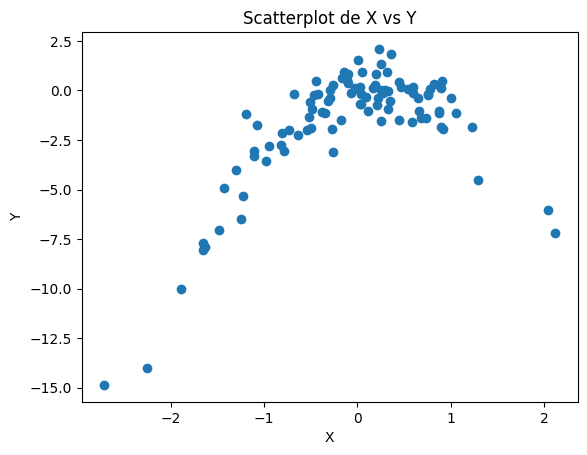

In [ ]:
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot de X vs Y")
plt.show()

Muestra una relación no lineal entre X y Y, con una forma curva similar a una parábola invertida. Esto indica que la relación entre las variables es cuadrática.

**c) Fija una semilla aleatoria y luego calcula los errores LOOCV al ajustar los siguientes modelos usando mínimos cuadrados:**

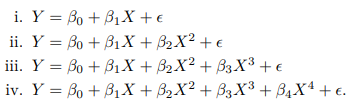

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
np.random.seed(1)

In [ ]:
df = pd.DataFrame({'x': x, 'y': y})

In [ ]:
def loocv_error(X, y):
    n = len(y)
    errors = []

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)[0]

        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

In [ ]:
errors = []

for degree in range(1, 5):
    X = np.column_stack([x**d for d in range(1, degree+1)])
    error = loocv_error(X, y)
    errors.append(error)
errors

[np.float64(6.633029839181983),
 np.float64(1.1229368563419673),
 np.float64(1.3017965489358851),
 np.float64(1.332394269417935)]

Los errores LOOCV obtenidos muestran que el modelo de grado 2 presenta el menor error. Esto indica que el modelo cuadrático es el que mejor se ajusta a los datos.

**d) Repite el inciso (c) usando otra semilla aleatoria y reporta tus resultados. ¿Son los mismos resultados que obtuviste en (c)? ¿Por qué?**

In [ ]:
rng = np.random.default_rng(2)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In [ ]:
df = pd.DataFrame({'x': x, 'y': y})

In [ ]:
def loocv_error(X, y):
    n = len(y)
    errors = []

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)[0]

        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

In [ ]:
errors = []

for degree in range(1, 5):
    X = np.column_stack([x**d for d in range(1, degree+1)])
    error = loocv_error(X, y)
    errors.append(error)
errors

[np.float64(7.560603694358579),
 np.float64(0.984037174458258),
 np.float64(0.9682355765918605),
 np.float64(0.9659585554875685)]

No, los resultados no son exactamente los mismos que en (c), ya que al cambiar la semilla se generan datos diferentes.

Sin embargo, los errores siguen siendo más bajos para los modelos de grado 2 y 3.

**e) ¿Cuál de los modelos en (c) tuvo el menor error LOOCV? ¿Es esto lo que esperabas? Explica tu respuesta.**

El modelo de grado 2 tiene el menor error, lo cual es esperado porque los datos tienen forma cuadrática

**f) Comenta sobre la significancia estadística de los coeficientes obtenidos al ajustar cada uno de los modelos en (c) usando mínimos cuadrados. ¿Estos resultados concuerdan con las conclusiones obtenidas usando validación cruzada?**

Los términos de mayor grado no son significativos, y esto coincide con LOOCV, que indica que el modelo de grado 2 es el mejor

### **9. Ahora consideraremos el dataset Boston housing**

**a) Con base en este dataset, proporciona una estimación de la media poblacional de medv. Llama a esta estimación μ**

In [173]:
from ISLP import load_data

df = load_data("Boston")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [174]:
mu_hat = df["medv"].mean()
mu_hat

np.float64(22.532806324110677)

**b) Proporciona una estimación del error estándar de μ. Interpreta este resultado.**

In [175]:
s = df["medv"].std()
n = len(df)

In [176]:
se = s / np.sqrt(n)
se

np.float64(0.4088611474975351)

El error estándar es pequeño, lo que indica que la media es una estimación bastante estable

**c) Ahora estima el error estándar 𝜇 de usando bootstrap. ¿Cómo se compara con tu respuesta del inciso (b)?**

In [177]:
np.random.seed(1)

In [178]:
n = len(df)
boot_means = []

In [179]:
for i in range(1000):
    sample = df["medv"].sample(n, replace=True)
    boot_means.append(sample.mean())

boot_means = np.array(boot_means)

In [180]:
boot_se = boot_means.std()
boot_se

np.float64(0.412402701271868)

El error estándar estimado mediante bootstrap es aproximadamente 0.412, el cual es muy similar al obtenido en el inciso (b). Esto indica que ambos métodos producen estimaciones consistentes del error estándar de la media, lo que confirma que el resultado es confiable.

**d) Con base en tu estimación bootstrap del inciso (c), proporciona un intervalo de confianza del 95% para la media de medv. Compáralo con el resultado obtenido usando la regla de dos errores estándar: [ μ - 2SE, μ + 2SE]**


In [181]:
lower = mu_hat - 2 * boot_se
upper = mu_hat + 2 * boot_se

In [182]:
lower, upper

(np.float64(21.708000921566942), np.float64(23.35761172665441))

**e) Con base en este dataset, proporciona una estimación μmed para la mediana de medv en la población.**

In [183]:
median_hat = df["medv"].median()
median_hat

21.2

**f) Ahora queremos estimar el error estándar de la mediana μmed. No existe una fórmula simple para esto, por lo que debemos usar bootstrap. Comenta sobre tus resultados.**

In [184]:
np.random.seed(1)

In [185]:
n = len(df)
boot_medians = []

In [186]:
for i in range(1000):
    sample = df["medv"].sample(n, replace=True)
    boot_medians.append(sample.median())

boot_medians = np.array(boot_medians)

In [187]:
boot_se_median = boot_medians.std()
boot_se_median

np.float64(0.3745979044255317)

**g) Con base en este dataset, proporciona una estimación del percentil 10 de medv. Denota esta cantidad como μ0.1. (Puedes usar la función np.percentile())**

In [188]:
p10 = np.percentile(df["medv"], 10)
p10

np.float64(12.75)

**h) Usa bootstrap para estimar el error estándar del percentil 10. Comenta sobre tus resultados.**

In [189]:
np.random.seed(1)

In [190]:
n = len(df)
boot_p10 = []

In [191]:
for i in range(1000):
    sample = df["medv"].sample(n, replace=True)
    boot_p10.append(np.percentile(sample, 10))

boot_p10 = np.array(boot_p10)

In [192]:
boot_se_p10 = boot_p10.std()
boot_se_p10

np.float64(0.48836343024432116)

El error estándar es aproximadamente 0.488, lo que indica que la estimación del percentil 10 es relativamente estable